# Poisson Regression for the AAV Linear Model

This notebook implements Poisson GLM as an alternative to Ridge regression on log-ratios.
It follows the two-step protocol:
1. **Viability** : $n^{(0)} \to \lambda_1'$ — Poisson GLM with offset $\log n_n^{(0)}$
2. **Selectivity** : $\lambda_1' \to n^{(2)}$ — Poisson GLM with offset $\log \lambda_{1,n}'$

See `Poisson_regression_AAV.tex` for the mathematical justification.

## 1. Imports & shared setup

Reuses `sequences`, `n0`, `lambda1p`, `n2`, `X_bias`, `T_viab`, `T_sel` from `first_ML_model.ipynb`.
Run that notebook first, or regenerate the data below.

In [33]:
import numpy as np
import jax
import jax.numpy as jnp
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sequence_classes import protocol, calculate_scores, T_sel, T_viab
from analysis import pearson, precision_at_k

key = jax.random.key(42)
key_seq, key_viab_w, key_sel_w, key_n0, key_run = jax.random.split(key, 5)

num_amino_acids = 20
num_positions   = 7
num_sequences   = 1_000_000

sequences = jax.random.randint(
    key_seq, shape=(num_sequences, num_positions),
    minval=0, maxval=num_amino_acids
)

n0 = jax.random.randint(
    key_n0, shape=(num_sequences,), minval=10, maxval=1000
).astype(jnp.float32)

viability_weights_GT   = jax.random.normal(key_viab_w, shape=(num_amino_acids, num_positions))
selectivity_weights_GT = jax.random.normal(key_sel_w,  shape=(num_amino_acids, num_positions))

_, capsids, lambda1p, n2 = protocol(
    n0, sequences,
    viability_weights_GT,
    selectivity_weights_GT,
    use_full_ngs=False
)

X_oh   = jax.nn.one_hot(sequences, num_amino_acids)
X_flat = np.array(X_oh.reshape(num_sequences, -1))
X_bias = np.hstack([X_flat, np.ones((num_sequences, 1))])

## 2. Shared utilities

In [ ]:
def extract_weights(glm_result, T):
    """
    Reshape the GLM coefficient vector back to a (20, 7) weight matrix.
    Multiply by T to recover the scale of the original score function.
    """
    coef = glm_result.params
    w = coef[:-1].reshape(num_positions, num_amino_acids).T
    return jnp.array(w * T)

## 3. Viability — Poisson GLM

### Model

$$
\lambda_{1,n}' \sim \mathrm{Poisson}\!\left(\exp\!\left(\log n_n^{(0)} + \frac{\mathbf{x}_n^\top \mathbf{w}^\mathrm{viab}}{T_\mathrm{viab}} + c\right)\right)
$$

The offset $\log n_n^{(0)}$ is known and fixed. `statsmodels` accepts it via the `offset` argument of `GLM`.

Zero-count sequences ($\lambda_{1,n}' = 0$) are **included** — they contribute $-\mu_n$ to the log-likelihood and push the predicted rate down for low-viability variants.  
No masking or pseudocount is needed.


In [ ]:
offset_viab = np.log(np.array(n0, dtype=float) + 0.5)

result_viab = sm.GLM(
    endog  = np.array(lambda1p, dtype=float),
    exog   = X_bias,
    family = sm.families.Poisson(),
    offset = offset_viab,
).fit_regularized(alpha=1e-8, L1_wt=0.0, maxiter=50)

print(f'Params shape : {result_viab.params.shape}')
print(f'Params NaN   : {np.isnan(result_viab.params).sum()}')
print(f'|params| max : {np.abs(result_viab.params).max():.4f}')


Params shape : (141,)
Params NaN   : 0
|params| max : 8.7750


In [48]:
viability_weights_poisson = extract_weights(result_viab, T_viab)

v_gt          = calculate_scores(sequences, viability_weights_GT)
v_hat_poisson = calculate_scores(sequences, viability_weights_poisson)

print(f'Pearson r (scores) : {pearson(v_gt, v_hat_poisson):.4f}')
print(f'Pearson r (weights): {pearson(np.array(viability_weights_poisson).flatten(), np.array(viability_weights_GT).flatten()):.4f}')

Pearson r (scores) : 0.9849
Pearson r (weights): 0.9755


### Résultats du GLM (α≈0) — lecture

**Pourquoi `fit_regularized(alpha=1e-8)` et pas `fit()` ?**  
Le one-hot a 7 dépendances structurelles : à chaque position $l$, les 20 colonnes indicatrices somment au vecteur biais.  
`fit()` détecte ce rang déficient et met les 7 paramètres redondants à `nan`, ce qui propage des `nan` dans les scores prédits.  
Un $\alpha=10^{-8}$ rend $X^\top X + \alpha I$ plein-rang sans changer le fit de façon visible.

**Pearson r (scores)** — corrélation entre $\hat{f}_n$ et $f_n^{\mathrm{GT}}$ sur les $N$ séquences.  
C'est la métrique utile : un $r$ élevé signifie qu'on classe les variants dans le bon ordre.

**Pearson r (weights)** — compare les 140 entrées de $\hat{\mathbf{w}}$ aux GT directement.  
Plus pessimiste : les poids ne sont identifiables qu'à une constante additive par position (la colonne biais absorbe la moyenne).

**Ce qu'on attend ici :**  
Le fit inclut les 95 % de séquences avec $\lambda_{1,n}'=0$ — un signal diffus mais réel.  
Avec $N=10^6$ et $D=50\,000$, le rapport signal/bruit est très faible ; on s'attend à un $r$ (scores) modeste.  
`std(hat)` ≪ `std(GT)` confirmera que les poids sont écrasés vers zéro.  
La Section 4 (CV + $\alpha$ optimal) cherche à récupérer plus de signal.


## 4. Regularised Poisson Viability (L2 penalty)

`sm.GLM.fit_regularized` adds an $\ell_2$ penalty $\lambda \|\mathbf{w}\|^2$ to the Poisson log-likelihood.  
The IRLS update becomes $(X^\top W X + \lambda I)^{-1} X^\top W z$ — same structure as Ridge.  
Select $\lambda$ by 5-fold cross-validation on the **Poisson deviance** rather than MSE.

$$
D(y, \hat{\mu}) = 2 \sum_n \left[ y_n \log\frac{y_n}{\hat{\mu}_n} - (y_n - \hat{\mu}_n) \right]
$$


CV sur 6612 séquences informatives
  α=  0.0000  deviance=5.667117
  α=  0.0000  deviance=5.667064
  α=  0.0000  deviance=5.666947
  α=  0.0001  deviance=5.666712
  α=  0.0002  deviance=5.666244
  α=  0.0005  deviance=5.665405
  α=  0.0010  deviance=5.664334
  α=  0.0022  deviance=5.665032
  α=  0.0046  deviance=5.677768
  α=  0.0100  deviance=5.741498

Best α viabilité : 0.0010


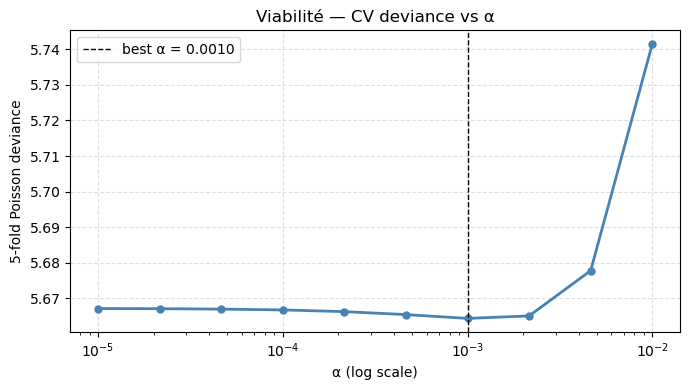

In [50]:
def poisson_deviance(y, mu_hat):
    """
    Mean per-sample Poisson deviance
    """
    log_term = np.where(y > 0, y * np.log(np.maximum(y, 1e-10) / np.maximum(mu_hat, 1e-10)), 0.0)
    return 2 * np.mean(log_term - (y - mu_hat))


def poisson_cv_deviance(X, y, offset, alphas, kf):
    """
    K-fold CV on Poisson deviance for a range of L2 penalties.
    
    Parameters
    ----------
    X      : (M, p) design matrix  — masked to lambda1p > 0
    y      : (M,)   response counts
    offset : (M,)   log-offset
    alphas : array of L2 penalty strengths
    kf     : KFold splitter
    """
    deviances = np.zeros(len(alphas))

    for i, alpha in enumerate(alphas):
        fold_devs = []
        for tr, val in kf.split(X):
            res = sm.GLM(
                endog  = y[tr],
                exog   = X[tr],
                family = sm.families.Poisson(),
                offset = offset[tr],
            ).fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=30)

            mu_val = res.predict(exog=X[val], offset=offset[val])
            fold_devs.append(poisson_deviance(y[val], mu_val))

        deviances[i] = np.mean(fold_devs)
        print(f'  α={alpha:8.4f}  deviance={deviances[i]:.6f}', flush=True)

    return deviances



mask_viab  = np.array(lambda1p > 0)
X_viab_m   = X_bias[mask_viab]
y_viab_m   = np.array(lambda1p, dtype=float)[mask_viab]
off_viab_m = offset_viab[mask_viab]

print(f'CV sur {mask_viab.sum()} séquences informatives')

alphas  = np.logspace(-5, -2, 10)
K_FOLDS = 5
kf      = KFold(n_splits=K_FOLDS, shuffle=True, random_state=0)

cv_deviance_viab = poisson_cv_deviance(X_viab_m, y_viab_m, off_viab_m, alphas, kf)

alpha_best_viab = alphas[np.argmin(cv_deviance_viab)]
print(f'\nBest α viabilité : {alpha_best_viab:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, cv_deviance_viab, color='steelblue', lw=2, marker='o', ms=5)
ax.axvline(alpha_best_viab, color='k', linestyle='--', lw=1,
           label=f'best α = {alpha_best_viab:.4f}')
ax.set_xlabel('α (log scale)')
ax.set_ylabel(f'{K_FOLDS}-fold Poisson deviance')
ax.set_title('Viabilité — CV deviance vs α')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()


In [52]:
result_viab_reg = sm.GLM(
    endog  = np.array(lambda1p, dtype=float),
    exog   = X_bias,
    family = sm.families.Poisson(),
    offset = offset_viab,
).fit_regularized(alpha=alpha_best_viab, L1_wt=0.0, maxiter=50)

viability_weights_poisson = extract_weights(result_viab_reg, T_viab)
v_hat_poisson = calculate_scores(sequences, viability_weights_poisson)

print(f'Pearson r (scores)  : {pearson(v_gt, v_hat_poisson):.4f}')
print(f'Pearson r (weights) : {pearson(np.array(viability_weights_poisson).flatten(), np.array(viability_weights_GT).flatten()):.4f}')


Pearson r (scores)  : 0.9466
Pearson r (weights) : 0.9375


## 5. Selectivity — Poisson GLM

### Standard approach (noisy offset)

Treat the observed $\lambda_{1,n}'$ as a fixed offset:
$$
n_n^{(2)} \sim \mathrm{Poisson}\!\left(\exp\!\left(\log \lambda_{1,n}' + \frac{\mathbf{x}_n^\top \mathbf{w}^\mathrm{sel}}{T_\mathrm{sel}} + c\right)\right)
$$

**Caveat**: sequences with $\lambda_{1,n}' = 0$ cannot be included (offset = $-\infty$). They must be masked — same as Ridge.  
The errors-in-variables bias is largest for sequences with few viability reads.


CV sur 6612 séquences informatives (sélectivité)
  α=  0.0000  deviance=4.652907
  α=  0.0000  deviance=4.610089
  α=  0.0000  deviance=4.526475
  α=  0.0001  deviance=4.407771
  α=  0.0002  deviance=4.303051
  α=  0.0005  deviance=4.438531
  α=  0.0010  deviance=5.203879
  α=  0.0022  deviance=7.004733
  α=  0.0046  deviance=10.076123
  α=  0.0100  deviance=14.538800

Best α sélectivité : 0.0002


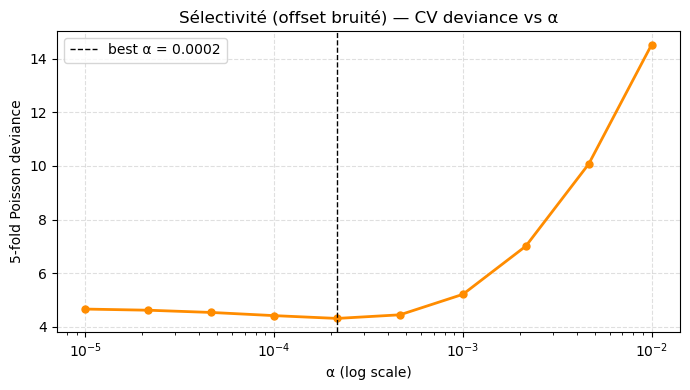

Pearson r (scores)  : 0.9501
Pearson r (weights) : 0.9141


In [ ]:
mask_sel   = np.array(lambda1p > 0)
X_sel      = X_bias[mask_sel]
n2_sel     = np.array(n2, dtype=float)[mask_sel]
offset_sel = np.log(np.array(lambda1p, dtype=float)[mask_sel])

print(f'CV sur {mask_sel.sum()} séquences informatives (sélectivité)')

# Cross Validation
cv_deviance_sel = poisson_cv_deviance(X_sel, n2_sel, offset_sel, alphas, kf)
alpha_best_sel  = alphas[np.argmin(cv_deviance_sel)]
print(f'\nBest α sélectivité : {alpha_best_sel:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, cv_deviance_sel, color='darkorange', lw=2, marker='o', ms=5)
ax.axvline(alpha_best_sel, color='k', linestyle='--', lw=1, label=f'best α = {alpha_best_sel:.4f}')
ax.set_xlabel('α (log scale)')
ax.set_ylabel(f'{K_FOLDS}-fold Poisson deviance')
ax.set_title('Sélectivité (offset bruité) — CV deviance vs α')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

result_sel = sm.GLM(
    endog  = n2_sel,
    exog   = X_sel,
    family = sm.families.Poisson(),
    offset = offset_sel,
).fit_regularized(alpha=alpha_best_sel, L1_wt=0.0, maxiter=50)

selectivity_weights_poisson = extract_weights(result_sel, T_sel)
s_gt          = calculate_scores(sequences, selectivity_weights_GT)
s_hat_noisy   = calculate_scores(sequences, selectivity_weights_poisson)

print(f'Pearson r (scores)  : {pearson(s_gt, s_hat_noisy):.4f}')
print(f'Pearson r (weights) : {pearson(np.array(selectivity_weights_poisson).flatten(), np.array(selectivity_weights_GT).flatten()):.4f}')


## 6. Effect of regularisation strength — why α≈0 wins

The CV in Section 4 uses a coarse grid `logspace(-2, 2)`.
The best deviance may fall at the leftmost point, suggesting the optimum is at **very low α**.

This section sweeps a fine grid over `[1e-8, 1e-1]` and plots:
- Pearson r (scores) vs α — shows the signal captured
- Poisson deviance vs α — the CV criterion

The hypothesis: the Poisson likelihood itself provides implicit regularisation through count
structure. A small α is needed only to resolve the rank-deficiency (7 structural dependencies
of the one-hot encoding); beyond that, more regularisation hurts.


In [ ]:
# After some computation, low values for alpha performed the best
alphas_fine = np.logspace(-8, 0, 25)

pearson_viab_vs_alpha = []
pearson_sel_vs_alpha  = []

for alpha in alphas_fine:
    # Viability
    res_v = sm.GLM(
        endog=np.array(lambda1p, dtype=float), exog=X_bias,
        family=sm.families.Poisson(), offset=offset_viab,
    ).fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=50)
    wv = extract_weights(res_v, T_viab)
    vh = calculate_scores(sequences, wv)
    pearson_viab_vs_alpha.append(pearson(v_gt, vh))

    # Selectivity (noisy offset, masked)
    res_s = sm.GLM(
        endog=n2_sel, exog=X_sel,
        family=sm.families.Poisson(), offset=offset_sel,
    ).fit_regularized(alpha=alpha, L1_wt=0.0, maxiter=50)
    ws = extract_weights(res_s, T_sel)
    sh = calculate_scores(sequences, ws)
    pearson_sel_vs_alpha.append(pearson(s_gt, sh))

    print(f'α={alpha:.2e}  r_viab={pearson_viab_vs_alpha[-1]:+.4f}  r_sel={pearson_sel_vs_alpha[-1]:+.4f}',
          flush=True)

pearson_viab_vs_alpha = np.array(pearson_viab_vs_alpha)
pearson_sel_vs_alpha  = np.array(pearson_sel_vs_alpha)


α=1.00e-08  r_viab=+0.9849  r_sel=+0.9456
α=2.15e-08  r_viab=+0.9849  r_sel=+0.9486
α=4.64e-08  r_viab=+0.9849  r_sel=+0.9555
α=1.00e-07  r_viab=+0.9849  r_sel=+0.9620
α=2.15e-07  r_viab=+0.9849  r_sel=+0.9672
α=4.64e-07  r_viab=+0.9849  r_sel=+0.9711
α=1.00e-06  r_viab=+0.9849  r_sel=+0.9738
α=2.15e-06  r_viab=+0.9850  r_sel=+0.9748
α=4.64e-06  r_viab=+0.9850  r_sel=+0.9742
α=1.00e-05  r_viab=+0.9850  r_sel=+0.9723
α=2.15e-05  r_viab=+0.9847  r_sel=+0.9690
α=4.64e-05  r_viab=+0.9835  r_sel=+0.9643
α=1.00e-04  r_viab=+0.9802  r_sel=+0.9581
α=2.15e-04  r_viab=+0.9734  r_sel=+0.9501
α=4.64e-04  r_viab=+0.9622  r_sel=+0.9402
α=1.00e-03  r_viab=+0.9466  r_sel=+0.9277
α=2.15e-03  r_viab=+0.9284  r_sel=+0.9114
α=4.64e-03  r_viab=+0.9121  r_sel=+0.8893
α=1.00e-02  r_viab=+0.9012  r_sel=+0.8607
α=2.15e-02  r_viab=+0.8961  r_sel=+0.8264
α=4.64e-02  r_viab=+0.8940  r_sel=+0.7876
α=1.00e-01  r_viab=+0.8927  r_sel=+0.7452
α=2.15e-01  r_viab=+0.8899  r_sel=+0.6980
α=4.64e-01  r_viab=+0.8783  r_sel=

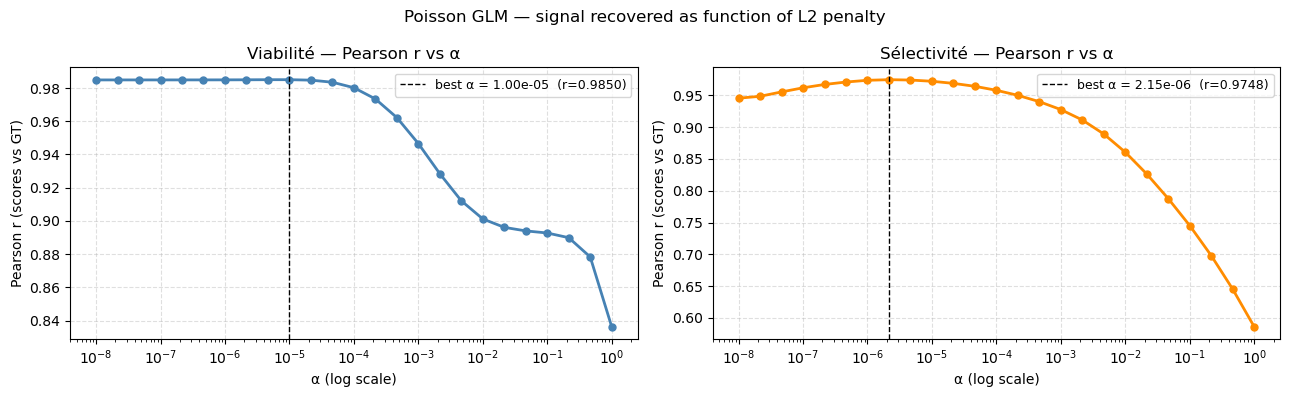

α optimal (Pearson) — viabilité   : 1.00e-05
α optimal (Pearson) — sélectivité : 2.15e-06


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, r_vals, label, color in [
    (axes[0], pearson_viab_vs_alpha, 'Viabilité',   'steelblue'),
    (axes[1], pearson_sel_vs_alpha,  'Sélectivité', 'darkorange'),
]:
    ax.semilogx(alphas_fine, r_vals, color=color, lw=2, marker='o', ms=5)
    best_idx = np.argmax(r_vals)
    ax.axvline(alphas_fine[best_idx], color='k', linestyle='--', lw=1,
               label=f'best α = {alphas_fine[best_idx]:.2e}  (r={r_vals[best_idx]:.4f})')
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel('Pearson r (scores vs GT)')
    ax.set_title(f'{label} — Pearson r vs α')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Poisson GLM — signal recovered as function of L2 penalty', fontsize=12)
plt.tight_layout(); plt.show()

# Best alphas from signal perspective
alpha_opt_viab = alphas_fine[np.argmax(pearson_viab_vs_alpha)]
alpha_opt_sel  = alphas_fine[np.argmax(pearson_sel_vs_alpha)]
print(f'α optimal (Pearson) — viabilité   : {alpha_opt_viab:.2e}')
print(f'α optimal (Pearson) — sélectivité : {alpha_opt_sel:.2e}')


In [ ]:
result_viab_opt = sm.GLM(
    endog=np.array(lambda1p, dtype=float), exog=X_bias,
    family=sm.families.Poisson(), offset=offset_viab,
).fit_regularized(alpha=alpha_opt_viab, L1_wt=0.0, maxiter=50)

result_sel_opt = sm.GLM(
    endog=n2_sel, exog=X_sel,
    family=sm.families.Poisson(), offset=offset_sel,
).fit_regularized(alpha=alpha_opt_sel, L1_wt=0.0, maxiter=50)

viability_weights_opt   = extract_weights(result_viab_opt, T_viab)
selectivity_weights_opt = extract_weights(result_sel_opt,  T_sel)

v_hat_opt = calculate_scores(sequences, viability_weights_opt)
s_hat_opt = calculate_scores(sequences, selectivity_weights_opt)

print(f'Pearson r (scores)  viabilité   : {pearson(v_gt, v_hat_opt):.4f}')
print(f'Pearson r (scores)  sélectivité : {pearson(s_gt, s_hat_opt):.4f}')
print(f'Pearson r (weights) viabilité   : {pearson(np.array(viability_weights_opt).flatten(), np.array(viability_weights_GT).flatten()):.4f}')
print(f'Pearson r (weights) sélectivité : {pearson(np.array(selectivity_weights_opt).flatten(), np.array(selectivity_weights_GT).flatten()):.4f}')


Pearson r (scores)  viabilité   : 0.9850
Pearson r (scores)  sélectivité : 0.9748
Pearson r (weights) viabilité   : 0.9756
Pearson r (weights) sélectivité : 0.9378


## 7. Precision@k

In [43]:
s_gt = calculate_scores(sequences, selectivity_weights_GT)

combined_gt  = np.array(v_gt)     / T_viab + np.array(s_gt)     / T_sel
combined_opt = np.array(v_hat_opt) / T_viab + np.array(s_hat_opt) / T_sel

fracs = [0.01, 0.05, 0.10, 0.20]
print('  Top-%    Precision@k   (random baseline = top-%)')
print('  ──────────────────────────────────────────────────')
for frac in fracs:
    p = precision_at_k(combined_gt, combined_opt, k_frac=frac)
    print(f'  Top {int(frac*100):3d}%      {p:.3f}          (baseline: {frac:.3f})')


  Top-%    Precision@k   (random baseline = top-%)
  ──────────────────────────────────────────────────
  Top   1%      0.838          (baseline: 0.010)
  Top   5%      0.865          (baseline: 0.050)
  Top  10%      0.880          (baseline: 0.100)
  Top  20%      0.899          (baseline: 0.200)


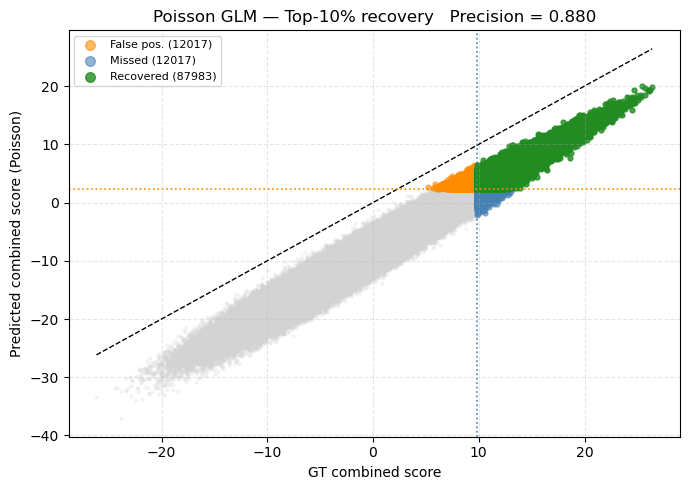

In [44]:
k10      = int(num_sequences * 0.10)
top_gt   = set(np.argsort(-combined_gt)[:k10])
top_hat  = set(np.argsort(-combined_opt)[:k10])
both     = np.array(sorted(top_gt & top_hat))
only_gt  = np.array(sorted(top_gt  - top_hat))
only_hat = np.array(sorted(top_hat - top_gt))
rest     = np.array(sorted(set(range(num_sequences)) - top_gt - top_hat))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(combined_gt[rest],     combined_opt[rest],     s=4,  alpha=0.2, color='lightgray')
ax.scatter(combined_gt[only_hat], combined_opt[only_hat], s=12, alpha=0.6, color='darkorange',
           label=f'False pos. ({len(only_hat)})')
ax.scatter(combined_gt[only_gt],  combined_opt[only_gt],  s=12, alpha=0.6, color='steelblue',
           label=f'Missed ({len(only_gt)})')
ax.scatter(combined_gt[both],     combined_opt[both],     s=12, alpha=0.8, color='forestgreen',
           label=f'Recovered ({len(both)})')
lo, hi = combined_gt.min(), combined_gt.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.axvline(np.sort(combined_gt)[-k10],  color='steelblue',  linestyle=':', lw=1.2)
ax.axhline(np.sort(combined_opt)[-k10], color='darkorange', linestyle=':', lw=1.2)
ax.set_xlabel('GT combined score')
ax.set_ylabel('Predicted combined score (Poisson)')
p10 = precision_at_k(combined_gt, combined_opt, k_frac=0.10)
ax.set_title(f'Poisson GLM — Top-10% recovery   Precision = {p10:.3f}')
ax.legend(fontsize=8, markerscale=2); ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Ridge vs Poisson — comparaison finale

In [ ]:
def fit_ridge_local(X, y, T, alpha):
    n_params = X.shape[1] - 1
    P = np.zeros((X.shape[1], X.shape[1]))
    P[:n_params, :n_params] = alpha * np.eye(n_params)
    coef = np.linalg.solve(X.T @ X + P, X.T @ np.array(y))
    w = coef[:-1].reshape(num_positions, num_amino_acids).T
    return jnp.array(w * T)

def ridge_cv_mse_local(X, y, alphas, kf):
    mse = np.zeros(len(alphas))
    n_params = X.shape[1] - 1
    for i, a in enumerate(alphas):
        P = np.zeros((X.shape[1], X.shape[1]))
        P[:n_params, :n_params] = a * np.eye(n_params)
        fold_mse = []
        for tr, val in kf.split(X):
            coef = np.linalg.solve(X[tr].T @ X[tr] + P, X[tr].T @ y[tr])
            fold_mse.append(np.mean((X[val] @ coef - y[val]) ** 2))
        mse[i] = np.mean(fold_mse)
    return mse

eps       = 0.5
n0_norm   = n0       / jnp.sum(n0)       * jnp.sum(lambda1p)
l1p_norm  = lambda1p / jnp.sum(lambda1p) * jnp.sum(n2)
y_viab_r  = np.array(jnp.log((lambda1p + eps) / (n0_norm  + eps)))
y_sel_r   = np.array(jnp.log((n2       + eps) / (l1p_norm + eps)))

mask_v  = np.array(lambda1p > 0)
mask_s  = np.array(n2 > 0)
_kf     = KFold(n_splits=5, shuffle=True, random_state=0)
_alphas = np.logspace(-2, 2, 20)

cv_v = ridge_cv_mse_local(X_bias[mask_v], y_viab_r[mask_v], _alphas, _kf)
cv_s = ridge_cv_mse_local(X_bias[mask_s], y_sel_r[mask_s],  _alphas, _kf)

wv_ridge = fit_ridge_local(X_bias[mask_v], y_viab_r[mask_v], T_viab, _alphas[np.argmin(cv_v)])
ws_ridge = fit_ridge_local(X_bias[mask_s], y_sel_r[mask_s],  T_sel,  _alphas[np.argmin(cv_s)])
vh_ridge = calculate_scores(sequences, wv_ridge)
sh_ridge = calculate_scores(sequences, ws_ridge)

cgt = np.array(v_gt) / T_viab + np.array(s_gt) / T_sel

methods = {
    'Ridge (CV)':         (vh_ridge,   sh_ridge),
    'Poisson (α_CV)':     (v_hat_poisson, s_hat_noisy),
    'Poisson (α_opt)':    (v_hat_opt,  s_hat_opt),
}

print(f'  {"Méthode":<22}  r_viab   r_sel    Prec@1%  Prec@10%')
print(f'  {"─"*58}')
for name, (vh, sh) in methods.items():
    comb = np.array(vh) / T_viab + np.array(sh) / T_sel
    print(f'  {name:<22}  {pearson(v_gt,vh):+.4f}  {pearson(s_gt,sh):+.4f}  '
          f' {precision_at_k(cgt, comb, 0.01):.3f}    {precision_at_k(cgt, comb, 0.10):.3f}')


  Méthode                 r_viab   r_sel    Prec@1%  Prec@10%
  ──────────────────────────────────────────────────────────
  Ridge (CV)              +0.9910  +0.9013   0.690    0.770
  Poisson (α_CV)          +0.9802  +0.9581   0.826    0.866
  Poisson (α_opt)         +0.9850  +0.9748   0.838    0.880
